# AUC of ROC : Diabetes Dataset

AUC-ROC stands for:

- ROC = Receiver Operating Characteristic curve
- AUC = Area Under the ROC Curve

It is a metric used to evaluate binary classification models.

### Application
- Medical diagnosis
- Fraud detection
- Spam filtering

### use True Positive Rate (recall) & False Positive Rate

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

In [2]:
data = pd.read_csv("../data_set/diabetes_diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
X = data.iloc[:, 0:-1]
y = data.iloc[:, -1]

In [4]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [5]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [7]:
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [8]:
model_svc = SVC(random_state=42)
model_svc.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [9]:
# decision_function() is a method that returns the raw decision score of a classifier instead of the final class label.
y_pred_svm = model_svc.decision_function(X_test)
print(y_pred_svm)

[-0.52370674 -1.58026098 -1.23195789 -0.85270599 -0.13190805 -0.04688499
 -1.7001829   0.02951194  0.6674055   0.5103676  -0.87251812  0.59896501
 -0.58395354  0.02755288 -1.60447944 -0.34029172 -1.49171807 -1.65381374
  0.70075158  0.00298414 -0.53411581 -1.62040017 -0.22594509 -1.67697559
  0.0631589   1.37855594 -1.17544699 -1.68175121 -1.38913364 -1.13557605
  0.66988229  0.93171077  1.09991275  1.18549539  0.47696328  0.95408536
 -0.11648506 -0.27832993 -1.25765397  0.91112613 -1.51510627 -0.02083514
  0.13794297 -0.74822487 -1.75853422  0.25662788  0.2146313  -1.18867898
 -1.01731892  0.70651235 -1.5758413   0.65803549  1.0485633  -0.73981456
 -1.34037977 -1.72388673  0.532478   -1.02886645 -0.4240509   1.58846504
  0.78755693 -0.71101191 -0.15853574 -0.22216927 -1.74930454  0.185035
 -1.59370519  0.03005532 -1.7110375  -0.41934254  0.79723293 -1.78661183
 -1.49662925 -1.76567155 -1.20420986 -0.35317736 -0.67005722 -1.18132981
 -1.276071   -1.24045253  1.10233501 -1.25511642 -1.4

In [10]:
model_logistic = LogisticRegression()
model_logistic.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [11]:
y_pred_logistic = model_logistic.decision_function(X_test)
print(y_pred_logistic)

[-0.95757577 -1.47647944 -2.04402491 -1.57576451 -0.12641637 -0.24137937
 -4.10690462  0.66129471  0.14490783  1.21160498 -1.07771335  2.10525403
 -0.69522165 -0.78664902 -2.37179455 -0.46281966 -1.82022622 -2.49030931
  1.79721741  0.22177145 -1.33448641 -2.45482866  0.124994   -2.24896051
  0.14014882  1.99131222 -1.95088133 -3.44048717 -1.10921711 -1.99718875
  2.27943799  1.87710594  1.14011065  1.60704945  0.49166276  0.78113091
  3.32847556 -1.09993958  0.03499398  0.96239689 -2.5683968   0.38183827
  0.3300166  -0.7052479  -3.51746445  0.02790657  0.61976842 -1.236456
 -0.5333203   3.07365846 -2.9529389   0.68016494  1.44808932 -1.10897587
 -2.26251092 -3.11099874  1.21372043 -5.11079343 -0.35143795  1.08515979
  1.0238522  -0.62751789 -1.38270237 -1.28882494 -2.47179468  0.4776186
 -2.90372793  0.9743455  -3.20429396  0.92090992  0.73486105 -2.55632589
 -1.49653865 -2.04201296 -2.27981805  0.05975027 -1.59829662 -1.78780048
 -1.86490767 -1.18721766  0.62072431 -1.74767575 -2.69

In [12]:
logistic_fpr, logistic_tpr, threshold = roc_curve(y_test, y_pred_logistic)
auc_logistic = auc(logistic_fpr, logistic_tpr)
print(auc_logistic)

0.8146923783287419


In [13]:
svm_fpr, svm_tpr, threshold = roc_curve(y_test, y_pred_svm)
auc_svm = auc(svm_fpr, svm_tpr)
print(auc_svm)

0.8049586776859504


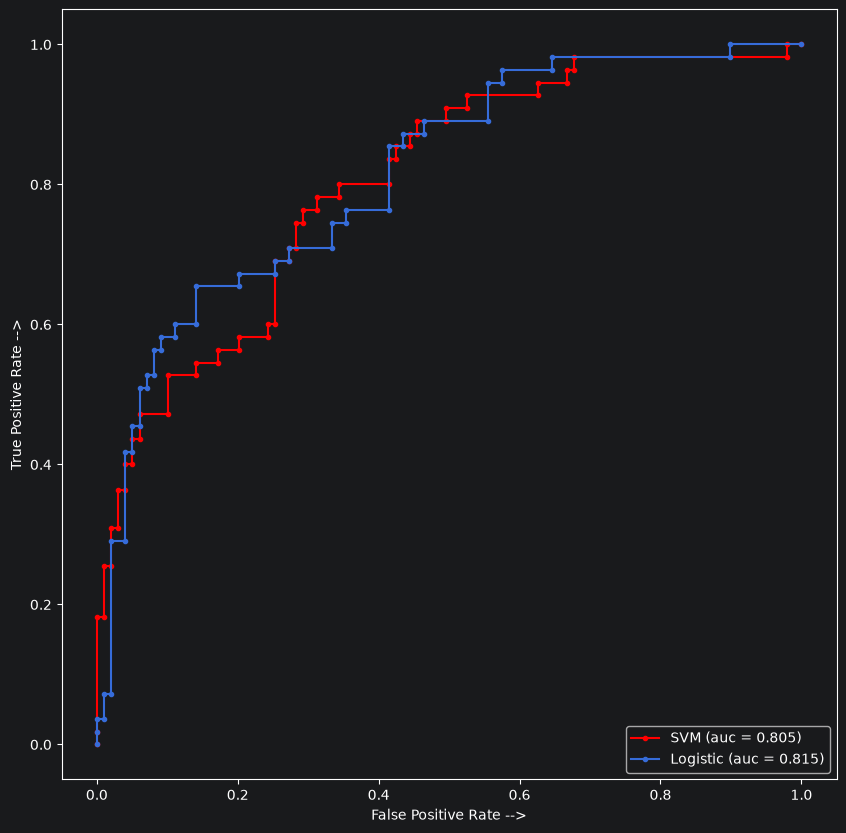

In [16]:
plt.figure(figsize=(10, 10))
plt.plot(
    svm_fpr,
    svm_tpr,
    marker=".",
    color="red",
    label="SVM (auc = %0.3f)" % auc_svm,
)
plt.plot(
    logistic_fpr,
    logistic_tpr,
    marker=".",
    label="Logistic (auc = %0.3f)" % auc_logistic,
)
plt.xlabel("False Positive Rate -->")
plt.ylabel("True Positive Rate -->")
plt.legend(loc="lower right")
plt.show()